<div style="background:#0D2137;padding:32px 36px 24px;border-radius:8px;margin-bottom:8px">
<h1 style="color:#FFFFFF;font-size:22px;font-weight:700;margin:0 0 10px">Bioassay Plate-Level QC Analysis System</h1>
<p style="color:#90CAF9;font-size:13px;margin:0 0 4px">ELISA & qPCR Quality Control  &nbsp;·&nbsp;  CV%, Recovery & Control Acceptance  &nbsp;·&nbsp;  GLP Compliance</p>
</div>
<div style="background:#F0F4F8;border-left:4px solid #00838F;padding:14px 18px;border-radius:0 6px 6px 0;margin-bottom:4px">
<table style="width:100%;font-size:13px;border-collapse:collapse">
<tr><td style="color:#546E7A;width:140px"><b>Author</b></td><td style="color:#0D2137">Harshitha Gudavalli</td></tr>
<tr><td style="color:#546E7A"><b>Degree</b></td><td style="color:#0D2137">M.S. Biomedical Engineering &amp; Biotechnology</td></tr>
<tr><td style="color:#546E7A"><b>Standard</b></td><td style="color:#0D2137">OECD GLP Principles &nbsp;·&nbsp; 21 CFR Part 58 &nbsp;·&nbsp; SOP: QA-SOP-BIO-003 Rev. 2</td></tr>
<tr><td style="color:#546E7A"><b>Stack</b></td><td style="color:#0D2137">Python &nbsp;·&nbsp; pandas &nbsp;·&nbsp; NumPy &nbsp;·&nbsp; Matplotlib &nbsp;·&nbsp; SciPy &nbsp;·&nbsp; openpyxl</td></tr>
</table>
</div>

---
## Project Background

In biotech and pharmaceutical research, every ELISA and qPCR plate run must be evaluated against defined QC acceptance criteria before the data from that plate can be used for analysis or decision-making. This is a core requirement under **GLP (Good Laboratory Practice)** — OECD Principles and **21 CFR Part 58**.

During my graduate studies in Biomedical Engineering and Biotechnology, I routinely ran ELISA and qPCR assays and understood firsthand how plate-to-plate variability can compromise data quality. A single plate with high CV% or poor recovery can invalidate an entire experiment if not caught at the QC stage.

This project builds an automated plate-level QC pipeline that evaluates every plate run against four GLP acceptance criteria:

| QC Criterion | Acceptance Limit | What it measures |
|---|---|---|
| **CV%** (Coefficient of Variation) | ≤ 15% | Replicate precision — how consistent are repeated measurements |
| **Recovery %** | 80% – 120% | Accuracy — how close is the measured value to the expected value |
| **Blank OD** | < 0.15 | Background signal — must be low to ensure signal specificity |
| **NSB OD** (Non-Specific Binding) | < 0.20 | Non-target binding — elevated NSB indicates assay interference |

Plates that fail any criterion are flagged for investigation. Weekly pass rates and failure trends are tracked to identify systemic issues early.

> All plate data in this notebook is simulated for demonstration purposes.

---
## Notebook Structure

| # | Section | Purpose |
|---|---|---|
| 1 | Setup | Import libraries and define acceptance criteria |
| 2 | Data Generation | Simulate 48 plate runs across ELISA and qPCR assays |
| 3 | QC Evaluation | Apply acceptance criteria, flag failures |
| 4 | Visualizations | QC trend dashboard — CV%, recovery, weekly pass rate |
| 5 | Failed Plate Investigation | Summarize all failing plates with failure reason |
| 6 | Excel Export | Professional audit-ready QC report |
| 7 | Summary | Final metrics and resume bullet |

---
## 1. Setup — Libraries & Acceptance Criteria

In [9]:
!pip install openpyxl scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from datetime import datetime, timedelta
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, LineChart, Reference
import warnings
warnings.filterwarnings('ignore')

# ── Visual theme ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#F0F4F8',
    'axes.facecolor':    '#FFFFFF',
    'axes.grid':         True,
    'grid.color':        '#E8EDF2',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

C = {
    'navy':  '#0D2137',
    'teal':  '#00838F',
    'blue':  '#1565C0',
    'green': '#2E7D32',
    'red':   '#C62828',
    'amber': '#E65100',
    'gray':  '#90A4AE',
}

# ── GLP Acceptance Criteria ───────────────────────────────────────────────────
# These limits are based on standard GLP practice for ELISA and qPCR assays
CV_LIMIT       = 15.0    # CV% must be ≤ 15% (replicate precision)
RECOVERY_LOW   = 80.0    # Recovery % lower bound
RECOVERY_HIGH  = 120.0   # Recovery % upper bound
BLANK_LIMIT    = 0.15    # Blank OD must be < 0.15
NSB_LIMIT      = 0.20    # Non-specific binding OD must be < 0.20

print('✔  Libraries ready.')
print()
print('  GLP Acceptance Criteria:')
print(f'    CV%          :  ≤ {CV_LIMIT}%')
print(f'    Recovery     :  {RECOVERY_LOW}% – {RECOVERY_HIGH}%')
print(f'    Blank OD     :  < {BLANK_LIMIT}')
print(f'    NSB OD       :  < {NSB_LIMIT}')

✔  Libraries ready.

  GLP Acceptance Criteria:
    CV%          :  ≤ 15.0%
    Recovery     :  80.0% – 120.0%
    Blank OD     :  < 0.15
    NSB OD       :  < 0.2


---
## 2. Data Generation — 48 Simulated Plate Runs

I simulate 48 plate runs across four assay types (ELISA and qPCR), spanning 12 weeks. Each plate has 8 replicates. About 18% of plates are assigned deviation-level values to reflect realistic lab failure rates.

In [2]:
np.random.seed(42)

ASSAY_TYPES = ['ELISA — IL-6', 'ELISA — TNF-α', 'qPCR — GAPDH', 'qPCR — β-Actin']
ANALYSTS    = ['H. Gudavalli', 'J. Patel', 'M. Rodriguez']
N_PLATES    = 48
START       = datetime(2024, 1, 8)

records = []

for i in range(N_PLATES):
    plate_id = f'PLT-{str(i+1).zfill(3)}'
    assay    = np.random.choice(ASSAY_TYPES)
    run_date = START + timedelta(days=i * 3)
    analyst  = np.random.choice(ANALYSTS)
    is_dev   = np.random.random() < 0.18      # ~18% failure rate

    # Simulate 8 replicates — standard plate format
    true_conc = np.random.uniform(50, 500)    # pg/mL concentration
    noise_sd  = 0.05 if not is_dev else np.random.uniform(0.18, 0.35)
    od_vals   = np.random.normal(true_conc * 0.002, true_conc * 0.002 * noise_sd, 8)
    od_vals   = np.clip(od_vals, 0.05, 3.5)

    mean_od  = round(np.mean(od_vals), 4)
    sd_od    = round(np.std(od_vals, ddof=1), 4)
    cv_pct   = round((sd_od / mean_od) * 100, 2) if mean_od > 0 else 0

    # Recovery: measured vs expected signal
    expected = true_conc * 0.002
    offset   = np.random.uniform(-0.08, 0.08) if not is_dev else np.random.uniform(-0.28, 0.28)
    measured = mean_od * (1 + offset)
    recovery = round((measured / expected) * 100, 1) if expected > 0 else 100.0

    # Plate controls
    blank_od = round(np.random.uniform(0.02, 0.08 if not is_dev else 0.22), 4)
    nsb_od   = round(np.random.uniform(0.05, 0.12 if not is_dev else 0.28), 4)
    pos_ctrl = round(np.random.uniform(1.8, 2.4 if not is_dev else 1.1), 4)
    neg_ctrl = round(np.random.uniform(0.05, 0.12 if not is_dev else 0.25), 4)

    # Apply acceptance criteria
    fails = []
    if cv_pct > CV_LIMIT:                                   fails.append('CV%')
    if not (RECOVERY_LOW <= recovery <= RECOVERY_HIGH):     fails.append('Recovery')
    if blank_od >= BLANK_LIMIT:                             fails.append('Blank OD')
    if nsb_od   >= NSB_LIMIT:                               fails.append('NSB')

    n      = len(fails)
    status = 'PASS' if n == 0 else 'FAIL'
    risk   = 'None' if n == 0 else ('Low' if n == 1 else ('Medium' if n == 2 else 'High'))

    records.append({
        'Plate_ID':         plate_id,
        'Assay_Type':       assay,
        'Run_Date':         run_date.strftime('%Y-%m-%d'),
        'Week':             f'Week {(i//4)+1:02d}',
        'Analyst':          analyst,
        'Replicates':       8,
        'Mean_OD':          mean_od,
        'SD_OD':            sd_od,
        'CV_Pct':           cv_pct,
        'CV_Limit':         CV_LIMIT,
        'CV_Pass':          'PASS' if cv_pct <= CV_LIMIT else 'FAIL',
        'Recovery_Pct':     recovery,
        'Recovery_Pass':    'PASS' if RECOVERY_LOW <= recovery <= RECOVERY_HIGH else 'FAIL',
        'Blank_OD':         blank_od,
        'Blank_Pass':       'PASS' if blank_od < BLANK_LIMIT else 'FAIL',
        'NSB_OD':           nsb_od,
        'NSB_Pass':         'PASS' if nsb_od < NSB_LIMIT else 'FAIL',
        'Pos_Control_OD':   pos_ctrl,
        'Neg_Control_OD':   neg_ctrl,
        'Failed_Criteria':  ', '.join(fails) if fails else 'None',
        'Risk_Level':       risk,
        'Plate_Status':     status,
        'SOP_Reference':    'QA-SOP-BIO-003 Rev. 2',
        'GLP_Standard':     'OECD GLP / 21 CFR Part 58',
    })

df     = pd.DataFrame(records)
passed = df[df['Plate_Status'] == 'PASS']
failed = df[df['Plate_Status'] == 'FAIL']
prate  = round(len(passed) / len(df) * 100, 1)

print(f'  Plate runs simulated  : {len(df)}')
print(f'  Plates passed         : {len(passed)}')
print(f'  Plates failed         : {len(failed)}')
print(f'  Overall pass rate     : {prate}%')
print(f'  Avg CV%               : {df["CV_Pct"].mean():.2f}%')
print(f'  Avg Recovery          : {df["Recovery_Pct"].mean():.1f}%')
print()

df.head(8)

  Plate runs simulated  : 48
  Plates passed         : 39
  Plates failed         : 9
  Overall pass rate     : 81.2%
  Avg CV%               : 8.06%
  Avg Recovery          : 99.1%



,Plate_ID,Assay_Type,Run_Date,Week,Analyst,Replicates,Mean_OD,SD_OD,CV_Pct,CV_Limit,...,Blank_Pass,NSB_OD,NSB_Pass,Pos_Control_OD,Neg_Control_OD,Failed_Criteria,Risk_Level,Plate_Status,SOP_Reference,GLP_Standard
0,PLT-001,qPCR — GAPDH,2024-01-08,Week 01,H. Gudavalli,8,0.7932,0.0422,5.32,15.0,...,PASS,0.0501,PASS,2.3953,0.0932,None,None,PASS,QA-SOP-BIO-003 Rev. 2,OECD GLP / 21 CFR Part 58
1,PLT-002,ELISA — TNF-α,2024-01-11,Week 01,J. Patel,8,0.1205,0.0184,15.27,15.0,...,PASS,0.0531,PASS,1.1405,0.1627,CV%,Low,FAIL,QA-SOP-BIO-003 Rev. 2,OECD GLP / 21 CFR Part 58
2,PLT-003,ELISA — TNF-α,2024-01-14,Week 01,H. Gudavalli,8,0.3249,0.0694,21.36,15.0,...,PASS,0.0572,PASS,1.2104,0.1400,CV%,Low,FAIL,QA-SOP-BIO-003 Rev. 2,OECD GLP / 21 CFR Part 58
3,PLT-004,ELISA — TNF-α,2024-01-17,Week 01,J. Patel,8,0.7736,0.0439,5.67,15.0,...,PASS,0.0693,PASS,1.9778,0.0616,None,None,PASS,QA-SOP-BIO-003 Rev. 2,OECD GLP / 21 CFR Part 58
4,PLT-005,ELISA — IL-6,2024-01-20,Week 02,M. Rodriguez,8,0.4591,0.0175,3.81,15.0,...,PASS,0.0966,PASS,2.1548,0.0692,None,None,PASS,QA-SOP-BIO-003 Rev. 2,OECD GLP / 21 CFR Part 58
5,PLT-006,qPCR — GAPDH,2024-01-23,Week 02,H. Gudavalli,8,0.9654,0.0308,3.19,15.0,...,PASS,0.0987,PASS,1.8836,0.0923,None,None,PASS,QA-SOP-BIO-003 Rev. 2,OECD GLP / 21 CFR Part 58
6,PLT-007,qPCR — GAPDH,2024-01-26,Week 02,M. Rodriguez,8,0.9545,0.0467,4.89,15.0,...,PASS,0.0727,PASS,1.8733,0.0749,None,None,PASS,QA-SOP-BIO-003 Rev. 2,OECD GLP / 21 CFR Part 58
7,PLT-008,ELISA — TNF-α,2024-01-29,Week 02,H. Gudavalli,8,0.6782,0.0483,7.12,15.0,...,PASS,0.0783,PASS,1.8389,0.0678,None,None,PASS,QA-SOP-BIO-003 Rev. 2,OECD GLP / 21 CFR Part 58


---
## 3. QC Evaluation — Acceptance Criteria Results

Break down how many plates failed each individual criterion and which assay types had the highest failure rates.

In [3]:
print('─' * 52)
print('  PLATE QC EVALUATION SUMMARY')
print('─' * 52)
print(f'  Total plates run   : {len(df)}')
print(f'  Passed             : {len(passed)}  ({prate}%)')
print(f'  Failed             : {len(failed)}')
print()

print('  Failures by QC criterion:')
for crit in ['CV%', 'Recovery', 'Blank OD', 'NSB']:
    n = failed['Failed_Criteria'].str.contains(crit).sum()
    print(f'    {crit:<14}  {"█" * n}  ({n} plates)')

print()
print('  Failures by assay type:')
print(failed['Assay_Type'].value_counts().to_string())

print()
print('  Risk level breakdown (failed plates):')
for r in ['High', 'Medium', 'Low']:
    print(f'    {r:<8}  {len(failed[failed["Risk_Level"]==r])}')

print('─' * 52)

failed[['Plate_ID','Assay_Type','Run_Date','CV_Pct','Recovery_Pct','Failed_Criteria','Risk_Level']].head(10)

────────────────────────────────────────────────────
  PLATE QC EVALUATION SUMMARY
────────────────────────────────────────────────────
  Total plates run   : 48
  Passed             : 39  (81.2%)
  Failed             : 9

  Failures by QC criterion:
    CV%             ████████  (8 plates)
    Recovery        █  (1 plates)
    Blank OD        ██  (2 plates)
    NSB             ██  (2 plates)

  Failures by assay type:
Assay_Type
qPCR — β-Actin    4
ELISA — TNF-α     3
ELISA — IL-6      1
qPCR — GAPDH      1

  Risk level breakdown (failed plates):
    High      1
    Medium    2
    Low       6
────────────────────────────────────────────────────


,Plate_ID,Assay_Type,Run_Date,CV_Pct,Recovery_Pct,Failed_Criteria,Risk_Level
1,PLT-002,ELISA — TNF-α,2024-01-11,15.27,109.9,CV%,Low
2,PLT-003,ELISA — TNF-α,2024-01-14,21.36,88.3,CV%,Low
15,PLT-016,ELISA — IL-6,2024-02-22,26.15,88.6,"CV%, Blank OD",Medium
22,PLT-023,ELISA — TNF-α,2024-03-14,13.87,85.5,NSB,Low
36,PLT-037,qPCR — β-Actin,2024-04-25,18.51,123.5,"CV%, Recovery, Blank OD",High
41,PLT-042,qPCR — β-Actin,2024-05-10,22.96,86.9,CV%,Low
43,PLT-044,qPCR — β-Actin,2024-05-16,27.24,96.5,CV%,Low
45,PLT-046,qPCR — β-Actin,2024-05-22,31.34,94.6,"CV%, NSB",Medium
47,PLT-048,qPCR — GAPDH,2024-05-28,16.53,82.8,CV%,Low


---
## 4. Visualizations — QC Trend Dashboard

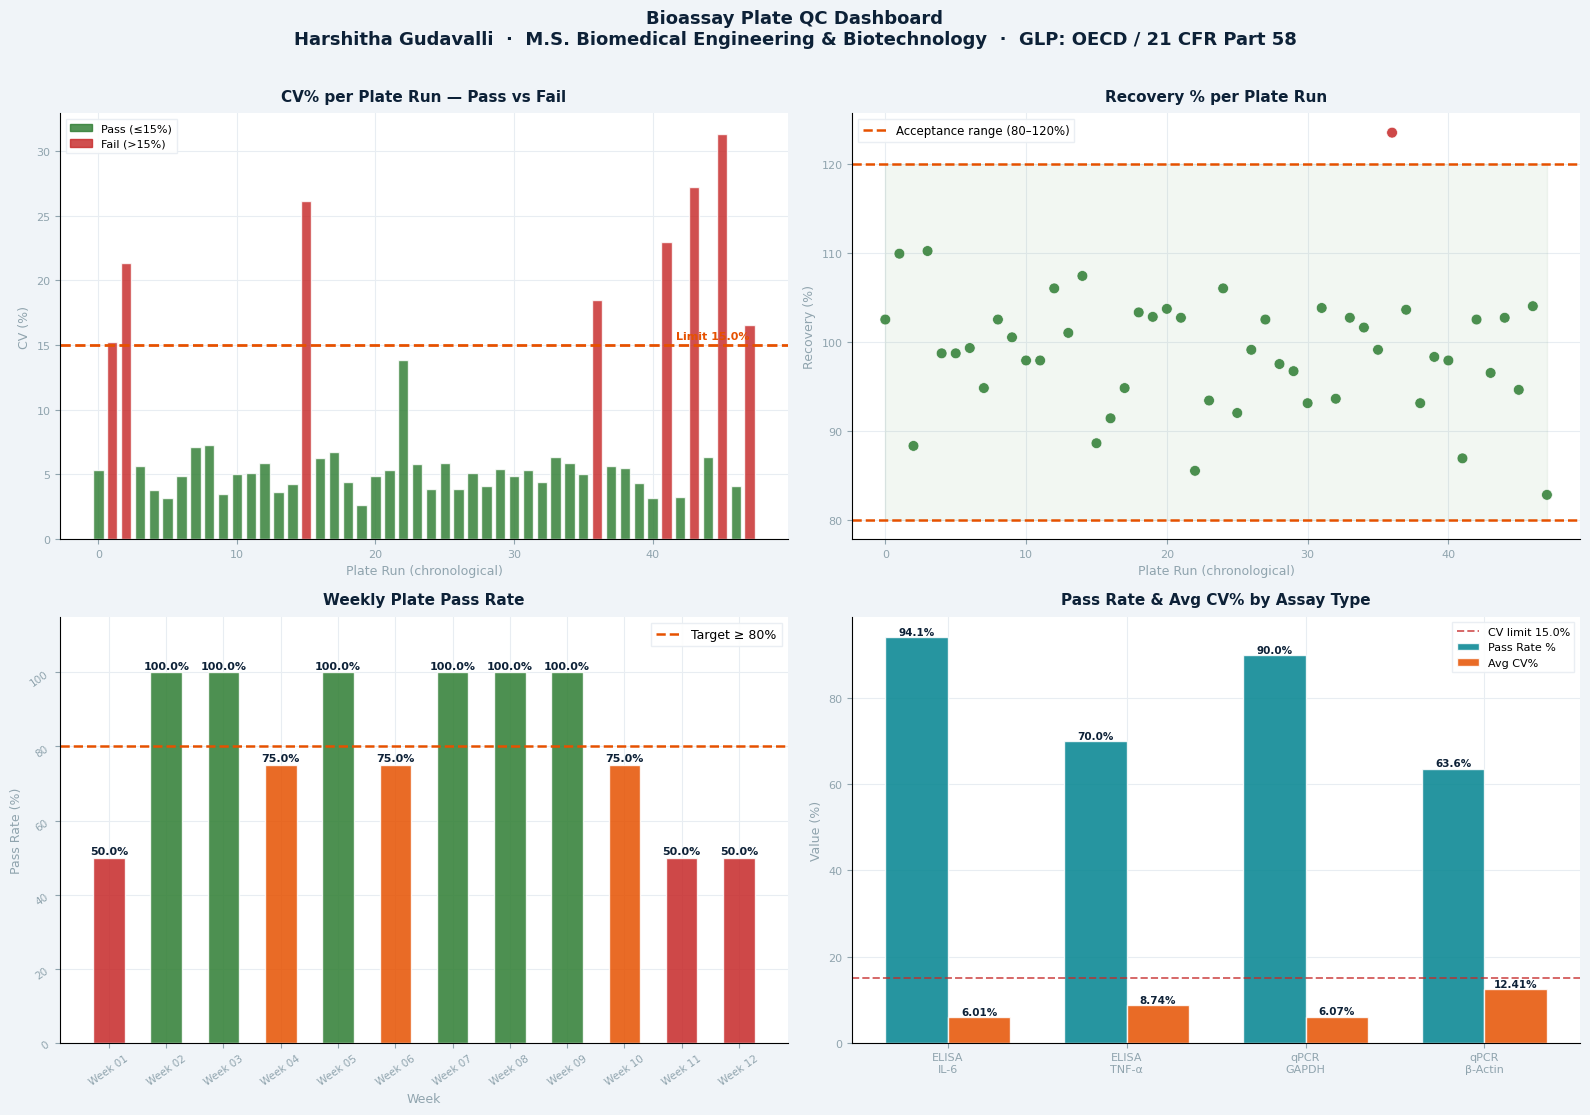

✔  Dashboard saved as BioassayQC_Dashboard_HGudavalli.png


In [4]:
weekly = df.groupby('Week').agg(
    Total  = ('Plate_ID', 'count'),
    Passed = ('Plate_Status', lambda x: (x=='PASS').sum()),
).reset_index()
weekly['Pass_Rate'] = (weekly['Passed'] / weekly['Total'] * 100).round(1)

by_assay = df.groupby('Assay_Type').agg(
    Total   = ('Plate_ID', 'count'),
    Pass    = ('Plate_Status', lambda x: (x=='PASS').sum()),
    Avg_CV  = ('CV_Pct', 'mean'),
).reset_index()
by_assay['Pass_Rate'] = (by_assay['Pass'] / by_assay['Total'] * 100).round(1)
by_assay['Avg_CV']    = by_assay['Avg_CV'].round(2)
by_assay['Short']     = by_assay['Assay_Type'].str.replace(' — ', '\n')

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Bioassay Plate QC Dashboard\n'
    'Harshitha Gudavalli  ·  M.S. Biomedical Engineering & Biotechnology  ·  GLP: OECD / 21 CFR Part 58',
    fontsize=13, fontweight='bold', color=C['navy'], y=1.01
)

# ── Chart 1: CV% per plate ────────────────────────────────────────────────────
ax = axes[0, 0]
bar_c = [C['green'] if v <= CV_LIMIT else C['red'] for v in df['CV_Pct']]
ax.bar(range(len(df)), df['CV_Pct'], color=bar_c, alpha=0.82, width=0.75, edgecolor='white')
ax.axhline(CV_LIMIT, color=C['amber'], linestyle='--', linewidth=2)
ax.text(len(df)-1, CV_LIMIT+0.5, f'Limit {CV_LIMIT}%', ha='right', fontsize=8, color=C['amber'], fontweight='bold')
p_p = mpatches.Patch(color=C['green'], alpha=0.82, label='Pass (≤15%)')
f_p = mpatches.Patch(color=C['red'],   alpha=0.82, label='Fail (>15%)')
ax.legend(handles=[p_p, f_p], fontsize=8, framealpha=0.9, edgecolor='#E8EDF2', fancybox=False)
ax.set_xlabel('Plate Run (chronological)', fontsize=9, color=C['gray'])
ax.set_ylabel('CV (%)', fontsize=9, color=C['gray'])
ax.set_title('CV% per Plate Run — Pass vs Fail', fontsize=11, fontweight='bold', color=C['navy'], pad=9)
ax.tick_params(colors=C['gray'], labelsize=8)
ax.set_axisbelow(True)

# ── Chart 2: Recovery scatter ─────────────────────────────────────────────────
ax = axes[0, 1]
rec_c = [C['green'] if RECOVERY_LOW <= r <= RECOVERY_HIGH else C['red'] for r in df['Recovery_Pct']]
ax.scatter(range(len(df)), df['Recovery_Pct'], c=rec_c, s=60, alpha=0.85,
           zorder=3, edgecolors='white', linewidth=0.5)
ax.axhline(RECOVERY_LOW,  color=C['amber'], linestyle='--', linewidth=1.8)
ax.axhline(RECOVERY_HIGH, color=C['amber'], linestyle='--', linewidth=1.8, label='Acceptance range (80–120%)')
ax.fill_between(range(len(df)), RECOVERY_LOW, RECOVERY_HIGH, alpha=0.06, color=C['green'])
ax.set_xlabel('Plate Run (chronological)', fontsize=9, color=C['gray'])
ax.set_ylabel('Recovery (%)', fontsize=9, color=C['gray'])
ax.set_title('Recovery % per Plate Run', fontsize=11, fontweight='bold', color=C['navy'], pad=9)
ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#E8EDF2', fancybox=False)
ax.tick_params(colors=C['gray'], labelsize=8)
ax.set_axisbelow(True)

# ── Chart 3: Weekly pass rate ─────────────────────────────────────────────────
ax = axes[1, 0]
wbc  = [C['green'] if r >= 80 else (C['amber'] if r >= 60 else C['red']) for r in weekly['Pass_Rate']]
bars = ax.bar(weekly['Week'], weekly['Pass_Rate'], color=wbc, alpha=0.85, width=0.55, edgecolor='white')
ax.axhline(80, color=C['amber'], linestyle='--', linewidth=1.8, label='Target ≥ 80%')
for bar, val in zip(bars, weekly['Pass_Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val}%', ha='center', fontsize=8, fontweight='bold', color=C['navy'])
ax.set_ylim(0, 115)
ax.set_xlabel('Week', fontsize=9, color=C['gray'])
ax.set_ylabel('Pass Rate (%)', fontsize=9, color=C['gray'])
ax.set_title('Weekly Plate Pass Rate', fontsize=11, fontweight='bold', color=C['navy'], pad=9)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#E8EDF2', fancybox=False)
ax.tick_params(colors=C['gray'], labelsize=7.5, rotation=35)
ax.set_axisbelow(True)

# ── Chart 4: Pass rate & avg CV by assay type ─────────────────────────────────
ax = axes[1, 1]
x   = np.arange(len(by_assay))
w   = 0.35
b1  = ax.bar(x-w/2, by_assay['Pass_Rate'], w, color=C['teal'],  alpha=0.85, label='Pass Rate %', edgecolor='white')
b2  = ax.bar(x+w/2, by_assay['Avg_CV'],    w, color=C['amber'], alpha=0.85, label='Avg CV%',     edgecolor='white')
ax.axhline(CV_LIMIT, color=C['red'], linestyle='--', linewidth=1.4, alpha=0.7, label=f'CV limit {CV_LIMIT}%')
for bar, val in zip(b1, by_assay['Pass_Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val}%', ha='center', fontsize=7.5, color=C['navy'], fontweight='bold')
for bar, val in zip(b2, by_assay['Avg_CV']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val}%', ha='center', fontsize=7.5, color=C['navy'], fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(by_assay['Short'], fontsize=8, color=C['gray'])
ax.set_ylabel('Value (%)', fontsize=9, color=C['gray'])
ax.set_title('Pass Rate & Avg CV% by Assay Type', fontsize=11, fontweight='bold', color=C['navy'], pad=9)
ax.legend(fontsize=8, framealpha=0.9, edgecolor='#E8EDF2', fancybox=False)
ax.tick_params(colors=C['gray'], labelsize=8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('BioassayQC_Dashboard_HGudavalli.png', dpi=150, bbox_inches='tight')
plt.show()
print('✔  Dashboard saved as BioassayQC_Dashboard_HGudavalli.png')

---
## 5. Failed Plate Investigation

Every failed plate requires a documented investigation. This section lists all failing plates with their failure reason and risk level, ready to hand off to the QA team.

In [5]:
print('─' * 60)
print('  FAILED PLATE INVESTIGATION LOG')
print('─' * 60)

inv_cols = ['Plate_ID', 'Assay_Type', 'Run_Date', 'Analyst',
            'CV_Pct', 'CV_Pass', 'Recovery_Pct', 'Recovery_Pass',
            'Blank_Pass', 'NSB_Pass', 'Failed_Criteria', 'Risk_Level']

fail_log = failed[inv_cols].copy().reset_index(drop=True)

print(f'  Total failed plates : {len(fail_log)}')
print()

# Statistical comparison: pass vs fail plates
t_stat, p_val = stats.ttest_ind(passed['CV_Pct'], failed['CV_Pct'])
print(f'  CV% statistics:')
print(f'    Pass plates   mean CV%  =  {passed["CV_Pct"].mean():.2f}%')
print(f'    Fail plates   mean CV%  =  {failed["CV_Pct"].mean():.2f}%')
print(f'    t-test p-value          =  {p_val:.4f}  {"(significant difference)" if p_val < 0.05 else ""}')
print()

print(f'  Recovery % statistics:')
print(f'    Pass plates   mean Rec% =  {passed["Recovery_Pct"].mean():.1f}%')
print(f'    Fail plates   mean Rec% =  {failed["Recovery_Pct"].mean():.1f}%')
print('─' * 60)

fail_log

────────────────────────────────────────────────────────────
  FAILED PLATE INVESTIGATION LOG
────────────────────────────────────────────────────────────
  Total failed plates : 9

  CV% statistics:
    Pass plates   mean CV%  =  4.96%
    Fail plates   mean CV%  =  21.47%
    t-test p-value          =  0.0000  (significant difference)

  Recovery % statistics:
    Pass plates   mean Rec% =  100.0%
    Fail plates   mean Rec% =  95.2%
────────────────────────────────────────────────────────────


,Plate_ID,Assay_Type,Run_Date,Analyst,CV_Pct,CV_Pass,Recovery_Pct,Recovery_Pass,Blank_Pass,NSB_Pass,Failed_Criteria,Risk_Level
0,PLT-002,ELISA — TNF-α,2024-01-11,J. Patel,15.27,FAIL,109.9,PASS,PASS,PASS,CV%,Low
1,PLT-003,ELISA — TNF-α,2024-01-14,H. Gudavalli,21.36,FAIL,88.3,PASS,PASS,PASS,CV%,Low
2,PLT-016,ELISA — IL-6,2024-02-22,H. Gudavalli,26.15,FAIL,88.6,PASS,FAIL,PASS,"CV%, Blank OD",Medium
3,PLT-023,ELISA — TNF-α,2024-03-14,J. Patel,13.87,PASS,85.5,PASS,PASS,FAIL,NSB,Low
4,PLT-037,qPCR — β-Actin,2024-04-25,J. Patel,18.51,FAIL,123.5,FAIL,FAIL,PASS,"CV%, Recovery, Blank OD",High
5,PLT-042,qPCR — β-Actin,2024-05-10,J. Patel,22.96,FAIL,86.9,PASS,PASS,PASS,CV%,Low
6,PLT-044,qPCR — β-Actin,2024-05-16,J. Patel,27.24,FAIL,96.5,PASS,PASS,PASS,CV%,Low
7,PLT-046,qPCR — β-Actin,2024-05-22,H. Gudavalli,31.34,FAIL,94.6,PASS,PASS,FAIL,"CV%, NSB",Medium
8,PLT-048,qPCR — GAPDH,2024-05-28,M. Rodriguez,16.53,FAIL,82.8,PASS,PASS,PASS,CV%,Low


---
## 6. Excel Export — Professional QC Report

In [10]:
OUTPUT  = 'BioassayQC_Report_HGudavalli.xlsx'
TODAY   = datetime.today().strftime('%Y-%m-%d')
AUTHOR  = 'Harshitha Gudavalli'
SOP_REF = 'QA-SOP-BIO-003 Rev. 2'

# ── Style helpers ─────────────────────────────────────────────────────────────
def thin_border():
    s = Side(style='thin', color='BFBFBF')
    return Border(left=s, right=s, top=s, bottom=s)

def hdr(ws, r, c, text, bg='0D2137', fg='FFFFFF', sz=10):
    cell           = ws.cell(r, c, text)
    cell.font      = Font(name='Calibri', size=sz, bold=True, color=fg)
    cell.fill      = PatternFill('solid', fgColor=bg)
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    cell.border    = thin_border()
    return cell

def body(ws, r, c, val, bg='FFFFFF', sz=9, bold=False, align='center'):
    cell           = ws.cell(r, c, val)
    cell.font      = Font(name='Calibri', size=sz, bold=bold)
    cell.fill      = PatternFill('solid', fgColor=bg)
    cell.alignment = Alignment(horizontal=align, vertical='center', wrap_text=True)
    cell.border    = thin_border()
    return cell

def banner(ws, ncols, row, text):
    ws.merge_cells(f'A{row}:{get_column_letter(ncols)}{row}')
    c = ws.cell(row, 1, text)
    c.font      = Font(name='Calibri', size=12, bold=True, color='FFFFFF')
    c.fill      = PatternFill('solid', fgColor='0D2137')
    c.alignment = Alignment(horizontal='center', vertical='center')
    ws.row_dimensions[row].height = 26

PF_BG  = {'PASS': 'E8F5E9', 'FAIL': 'FFEBEE'}
PF_FG  = {'PASS': '1B5E20', 'FAIL': 'B71C1C'}
RSK_BG = {'High': 'FFEBEE', 'Medium': 'FFF8E1', 'Low': 'E3F2FD', 'None': 'E8F5E9'}
RSK_FG = {'High': 'B71C1C', 'Medium': 'BF360C', 'Low': '0D47A1', 'None': '1B5E20'}

wb = Workbook()

# ── Sheet 1: Full QC Log ──────────────────────────────────────────────────────
ws1 = wb.active
ws1.title = 'QC Log — All Plates'

banner(ws1, 16, 1, f'BIOASSAY PLATE QC LOG  ·  GLP: OECD / 21 CFR Part 58  ·  {AUTHOR}  ·  {TODAY}')

cols1 = ['Plate ID','Assay Type','Run Date','Week','Analyst','Replicates',
         'Mean OD','SD OD','CV%','CV Limit','CV Pass',
         'Recovery%','Rec Pass','Blank OD','Blank Pass','NSB OD','NSB Pass',
         'Failed Criteria','Risk','Status']
keys1 = ['Plate_ID','Assay_Type','Run_Date','Week','Analyst','Replicates',
         'Mean_OD','SD_OD','CV_Pct','CV_Limit','CV_Pass',
         'Recovery_Pct','Recovery_Pass','Blank_OD','Blank_Pass','NSB_OD','NSB_Pass',
         'Failed_Criteria','Risk_Level','Plate_Status']
wds1  = [12,18,12,10,14,10,10,8,8,8,9,11,9,10,10,10,10,20,10,10]

for ci,(h,w) in enumerate(zip(cols1,wds1),1):
    hdr(ws1,2,ci,h)
    ws1.column_dimensions[get_column_letter(ci)].width = w

for ri,(_,row) in enumerate(df.iterrows()):
    er  = 3+ri
    alt = 'F7FAFC' if ri%2==0 else 'FFFFFF'
    for ci,key in enumerate(keys1,1):
        val = row[key]
        if key == 'Plate_Status':
            c = ws1.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=PF_FG.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=PF_BG.get(val,'FFFFFF'))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        elif key in ['CV_Pass','Recovery_Pass','Blank_Pass','NSB_Pass']:
            c = ws1.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=PF_FG.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=PF_BG.get(val,alt))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        elif key == 'Risk_Level':
            c = ws1.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=RSK_FG.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=RSK_BG.get(val,alt))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        else:
            body(ws1,er,ci,val,bg=alt)

ws1.freeze_panes = 'A3'
ws1.auto_filter.ref = f'A2:{get_column_letter(len(cols1))}2'

# ── Sheet 2: Failed Plates ────────────────────────────────────────────────────
ws2 = wb.create_sheet('Failed Plates — Investigation')
banner(ws2, 12, 1, f'FAILED PLATE INVESTIGATION LOG  ·  {len(failed)} Plates  ·  {SOP_REF}')

cols2 = ['Plate ID','Assay Type','Run Date','Analyst','CV%','CV Pass',
         'Recovery%','Rec Pass','Blank Pass','NSB Pass','Failed Criteria','Risk Level']
keys2 = ['Plate_ID','Assay_Type','Run_Date','Analyst','CV_Pct','CV_Pass',
         'Recovery_Pct','Recovery_Pass','Blank_Pass','NSB_Pass','Failed_Criteria','Risk_Level']
wds2  = [12,18,12,14,10,9,11,9,10,10,22,12]

for ci,(h,w) in enumerate(zip(cols2,wds2),1):
    hdr(ws2,2,ci,h)
    ws2.column_dimensions[get_column_letter(ci)].width = w

for ri,(_,row) in enumerate(failed.iterrows()):
    er  = 3+ri
    alt = 'F7FAFC' if ri%2==0 else 'FFFFFF'
    for ci,key in enumerate(keys2,1):
        val = row[key]
        if key in ['CV_Pass','Recovery_Pass','Blank_Pass','NSB_Pass']:
            c = ws2.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=PF_FG.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=PF_BG.get(val,alt))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        elif key == 'Risk_Level':
            c = ws2.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=RSK_FG.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=RSK_BG.get(val,alt))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        else:
            body(ws2,er,ci,val,bg=alt)

ws2.freeze_panes = 'A3'

# ── Sheet 3: Weekly Summary ───────────────────────────────────────────────────
ws3 = wb.create_sheet('Weekly Summary')
banner(ws3, 5, 1, f'WEEKLY PLATE QC SUMMARY  ·  {AUTHOR}  ·  {TODAY}')

wk_sum = df.groupby('Week').agg(
    Total      = ('Plate_ID','count'),
    Passed     = ('Plate_Status',lambda x:(x=='PASS').sum()),
    Failed     = ('Plate_Status',lambda x:(x=='FAIL').sum()),
    Avg_CV     = ('CV_Pct','mean'),
    Avg_Recov  = ('Recovery_Pct','mean'),
).reset_index()
wk_sum['Pass_Rate'] = (wk_sum['Passed']/wk_sum['Total']*100).round(1)
wk_sum['Avg_CV']    = wk_sum['Avg_CV'].round(2)
wk_sum['Avg_Recov'] = wk_sum['Avg_Recov'].round(1)

cols3 = ['Week','Total Plates','Passed','Failed','Pass Rate %','Avg CV%','Avg Recovery%']
keys3 = ['Week','Total','Passed','Failed','Pass_Rate','Avg_CV','Avg_Recov']
wds3  = [12,14,12,12,14,12,16]

for ci,(h,w) in enumerate(zip(cols3,wds3),1):
    hdr(ws3,2,ci,h)
    ws3.column_dimensions[get_column_letter(ci)].width = w

for ri,(_,row) in enumerate(wk_sum.iterrows()):
    er  = 3+ri
    alt = 'F7FAFC' if ri%2==0 else 'FFFFFF'
    for ci,key in enumerate(keys3,1):
        body(ws3,er,ci,row[key],bg=alt)

chart = BarChart()
chart.type   = 'col'
chart.title  = 'Weekly Plate Pass Rate (%)'
chart.style  = 10
chart.width  = 20
chart.height = 10
chart.add_data(Reference(ws3,min_col=5,max_col=5,min_row=2,max_row=2+len(wk_sum)),titles_from_data=True)
chart.set_categories(Reference(ws3,min_col=1,min_row=3,max_row=2+len(wk_sum)))
ws3.add_chart(chart,f'A{5+len(wk_sum)}')

wb.save(OUTPUT)
print(f'✔  Report saved: {OUTPUT}')
print(f'   Sheets: {[s.title for s in wb.worksheets]}')

try:
    from google.colab import files
    files.download(OUTPUT)
    print('✔  Download started.')
except:
    print('   (Open file from the Colab left sidebar → Files)')

✔  Report saved: BioassayQC_Report_HGudavalli.xlsx
   Sheets: ['QC Log — All Plates', 'Failed Plates — Investigation', 'Weekly Summary']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔  Download started.


---
## 7. Final Summary

In [7]:
d = '─' * 56
print(d)
print('  PROJECT SUMMARY — Project 2')
print('  Harshitha Gudavalli')
print('  M.S. Biomedical Engineering & Biotechnology')
print(d)
print(f'  GLP standard         :  OECD GLP / 21 CFR Part 58')
print(f'  Total plates         :  {len(df)}')
print(f'  Plates passed        :  {len(passed)}')
print(f'  Plates failed        :  {len(failed)}')
print(f'  Overall pass rate    :  {prate}%')
print(f'  Avg CV%              :  {df["CV_Pct"].mean():.2f}%')
print(f'  Avg Recovery         :  {df["Recovery_Pct"].mean():.1f}%')
print()
print('  Output files:')
print(f'    ✔  {OUTPUT}')
print(f'    ✔  BioassayQC_Dashboard_HGudavalli.png')
print(d)
print()
print('  Resume bullet:')
print('  "Developed a Python-based ELISA & qPCR plate QC')
print('  pipeline evaluating 48 plate runs against GLP')
print('  acceptance criteria — CV%, recovery %, blank OD,')
print('  and NSB — with automated pass/fail reporting and')
print('  weekly trend analysis per OECD GLP / 21 CFR Part 58."')
print(d)

────────────────────────────────────────────────────────
  PROJECT SUMMARY — Project 2
  Harshitha Gudavalli
  M.S. Biomedical Engineering & Biotechnology
────────────────────────────────────────────────────────
  GLP standard         :  OECD GLP / 21 CFR Part 58
  Total plates         :  48
  Plates passed        :  39
  Plates failed        :  9
  Overall pass rate    :  81.2%
  Avg CV%              :  8.06%
  Avg Recovery         :  99.1%

  Output files:
    ✔  BioassayQC_Report_HGudavalli.xlsx
    ✔  BioassayQC_Dashboard_HGudavalli.png
────────────────────────────────────────────────────────

  Resume bullet:
  "Developed a Python-based ELISA & qPCR plate QC
  pipeline evaluating 48 plate runs against GLP
  acceptance criteria — CV%, recovery %, blank OD,
  and NSB — with automated pass/fail reporting and
  weekly trend analysis per OECD GLP / 21 CFR Part 58."
────────────────────────────────────────────────────────
